## Question 4: Feature Selection:
The Iris dataset consists of 150 samples with 4 features each: sepal length, sepal width, petal
length, and petal width. Each sample belongs to one of three classes: setosa, versicolor, or
virginica.
* a. Load the Iris dataset and split it into features (X) and target labels (y).
* b. Perform exploratory data analysis (EDA) to gain insights into the dataset.
* c. Implement feature selection techniques:
* c - a. Univariate Feature Selection
* c - b. Feature Importance using Random Forest
* c - c. Recursive Feature Elimination (RFE) using Support Vector Machine (SVM)
* d. Evaluate the performance of the selected features using a classification model (e.g., SVM
or Logistic Regression).
* e. Compare the model performance before and after feature selection

Dataset loaded: 150 samples, 4 features.


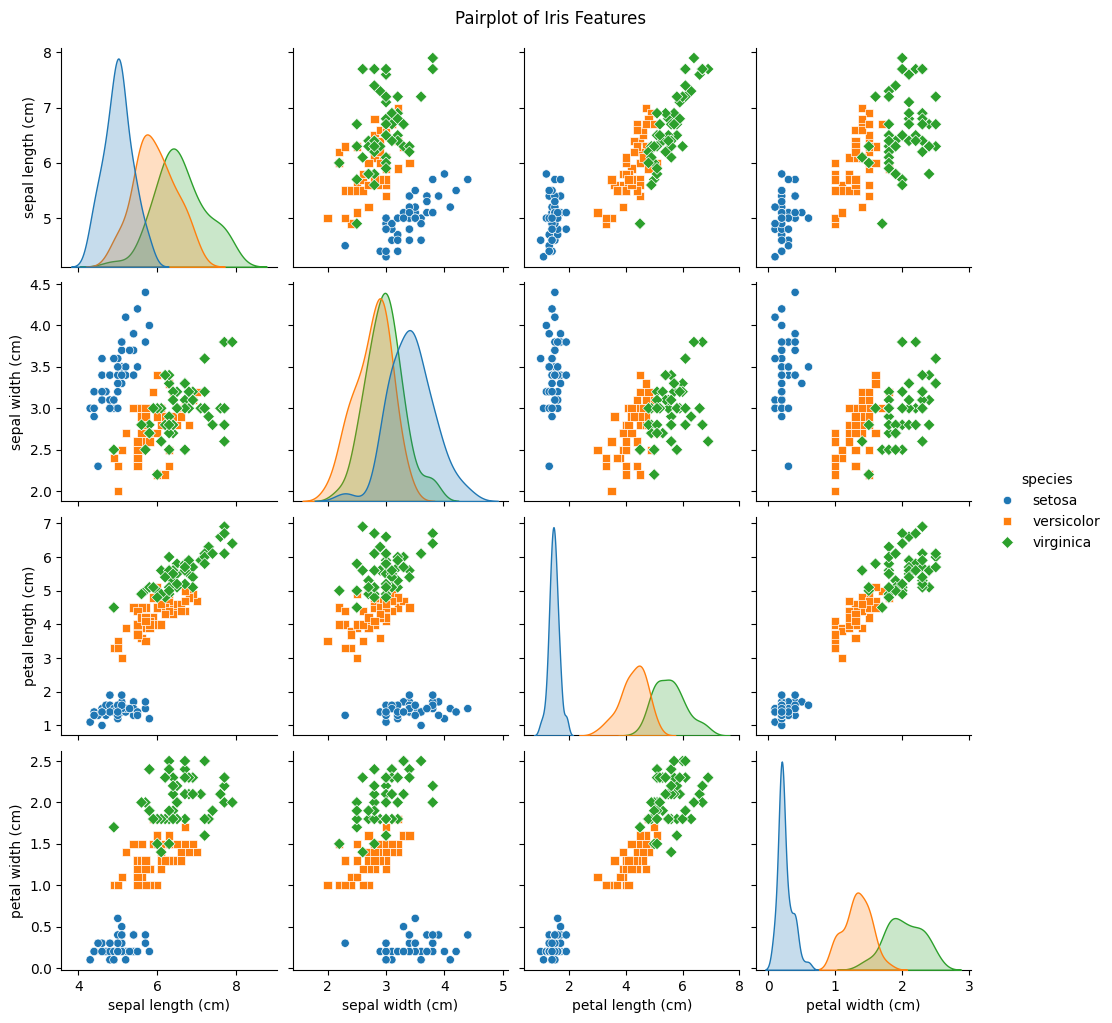

Univariate Selected: ['petal length (cm)', 'petal width (cm)']
Random Forest Selected: ['petal length (cm)', 'petal width (cm)']
RFE Selected: ['petal length (cm)', 'petal width (cm)']

--- Performance Comparison ---
               Method  Accuracy
0        All Features       1.0
1  Univariate (KBest)       1.0
2       RF Importance       1.0
3           RFE (SVM)       1.0


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- a. Load the Dataset ---
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
feature_names = iris.feature_names

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.")

# --- b. Exploratory Data Analysis (EDA) ---
df_eda = X.copy()
df_eda['species'] = [iris.target_names[i] for i in y]

sns.pairplot(df_eda, hue='species', markers=["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# --- c. Feature Selection Techniques ---

# 1. Univariate Feature Selection (SelectKBest)
selector_uni = SelectKBest(score_func=f_classif, k=2)
X_uni = selector_uni.fit_transform(X, y)
uni_support = X.columns[selector_uni.get_support()].tolist()

# 2. Feature Importance using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
rf_indices = np.argsort(importances)[::-1][:2]
rf_support = [feature_names[i] for i in rf_indices]

# 3. Recursive Feature Elimination (RFE) using SVM
svc = SVC(kernel="linear")
rfe = RFE(estimator=svc, n_features_to_select=2, step=1)
rfe.fit(X, y)
rfe_support = X.columns[rfe.get_support()].tolist()

print(f"Univariate Selected: {uni_support}")
print(f"Random Forest Selected: {rf_support}")
print(f"RFE Selected: {rfe_support}")

# --- d & e. Evaluate and Compare Performance ---

def evaluate_model(X_data, y_data, title):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    # Scale data for SVM
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = SVC(kernel='rbf')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return acc

# Performance Comparison
acc_full = evaluate_model(X, y, "All Features")
acc_uni = evaluate_model(X_uni, y, "Univariate")
acc_rf = evaluate_model(X[rf_support], y, "RF Importance")
acc_rfe = evaluate_model(X[rfe_support], y, "RFE")

performance_df = pd.DataFrame({
    'Method': ['All Features', 'Univariate (KBest)', 'RF Importance', 'RFE (SVM)'],
    'Accuracy': [acc_full, acc_uni, acc_rf, acc_rfe]
})

print("\n--- Performance Comparison ---")
print(performance_df)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Data (Pure Iris, no noise)
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. THE KEY CHANGE: Use a tiny training set (only 8% of the data)
# This leaves only ~12 samples for the model to learn from!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.08, random_state=42, stratify=y
)

def evaluate_subset(feature_indices):
    # Scale and train
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train.iloc[:, feature_indices])
    X_te = scaler.transform(X_test.iloc[:, feature_indices])

    # Use Logistic Regression (it's more sensitive to feature choice than SVM)
    model = LogisticRegression()
    model.fit(X_tr, y_train)
    return accuracy_score(y_test, model.predict(X_te))

# --- Feature Selection ---

# 1. All Features
acc_all = evaluate_subset(range(4))

# 2. Univariate Selection (Top 2)
uni = SelectKBest(f_classif, k=2).fit(X_train, y_train)
acc_uni = evaluate_subset(np.where(uni.get_support())[0])

# 3. RF Importance (Top 2)
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
rf_indices = np.argsort(rf.feature_importances_)[-2:]
acc_rf = evaluate_subset(rf_indices)

# 4. RFE with Logistic Regression (Top 2)
rfe = RFE(estimator=LogisticRegression(), n_features_to_select=2).fit(X_train, y_train)
acc_rfe = evaluate_subset(np.where(rfe.support_)[0])

# Results
results = pd.DataFrame({
    'Method': ['All Features', 'Univariate (KBest)', 'RF Importance', 'RFE'],
    'Accuracy': [acc_all, acc_uni, acc_rf, acc_rfe]
}).sort_values(by='Accuracy', ascending=False)

print(f"Training on only {len(X_train)} samples and using Logistic Regression: ")
print(results)

Training on only 12 samples and using Logistic Regression: 
               Method  Accuracy
1  Univariate (KBest)  0.956522
2       RF Importance  0.956522
3                 RFE  0.956522
0        All Features  0.927536


## Question 5: Association Rule Mining:
The objective of this lab exercise is to understand and
implement association rule mining techniques to uncover patterns and associations within
a given dataset of transactional data.
### B. Dataset:
* a. Take any dataset containing transactions from a grocery store. Each transaction consists of a list of items purchased by a customer. Utilizing association rule
mining techniques, analyze the dataset to uncover patterns and associations
between items purchased together.
* b. Load the provided dataset containing transactional data from a grocery store.
* c. Examine the structure of the dataset to understand the transactional format.
### C. Generating Itemsets:
* a. Implement a function to generate individual itemsets from the dataset.
* b. Calculate the support for each itemset, which represents the frequency of
occurrence of each item.
### D. Identifying Frequent Itemsets:
* a. Implement the Apriori algorithm to identify frequent itemsets within the
dataset.
* b. Determine the minimum support threshold for identifying frequent itemsets.
### E. Deriving Association Rules:
* a. Utilize the frequent itemsets obtained from the Apriori algorithm to derive
association rules.
* b. Calculate the confidence for each association rule, representing the likelihood of
one item being purchased given the purchase of another item.
* c. Set a minimum confidence threshold for selecting meaningful association rules.
### F. Evaluation of Association Rules:
* a. Evaluate the generated association rules using appropriate metrics such as
support, confidence, and lift.
* b. Identify high-confidence rules with significant lift values, indicating strong
associations between items.

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings

# Suppress DeprecationWarning from jupyter_client
warnings.filterwarnings('ignore', category=DeprecationWarning)

current_time = datetime.now(timezone.utc)
print(f"Analysis started at: {current_time}\n")

# B. Dataset: Loading and Examining
# b. Load from GitHub
url = "https://raw.githubusercontent.com/earlyann/grocery_market_basket_analysis/master/Groceries_dataset.csv"
df_raw = pd.read_csv(url)

# c. Examine structure
print("Dataset Structure:")
print(df_raw.info())
print("\nFirst 5 rows of transactional data:")
print(df_raw.head())

# C. Generating Itemsets
# a. Function to generate individual itemsets (grouping by member and date)
# We group by Member_number and Date to define a single 'transaction'
transactions = df_raw.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

# b. Calculate support (Frequency of occurrence)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nTotal Transactions: {len(transactions)}")
print(f"Total Unique Items: {len(te.columns_)}")

# D. Identifying Frequent Itemsets
# a. Implement Apriori
# b. Set minimum support threshold
min_support_threshold = 0.001
frequent_itemsets = apriori(df_encoded, min_support=min_support_threshold, use_colnames=True)

print("\nTop 5 Frequent Itemsets:")
print(frequent_itemsets.sort_values(by='support', ascending=False).head())

# E. Deriving Association Rules
# a. Derive rules from frequent itemsets
# b. Calculate confidence
# c. Set minimum confidence threshold (0.05 or 5%)
min_confidence = 0.05
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# F. Evaluation of Association Rules
# a. Metrics included: Support, Confidence, Lift
# b. Filter for strong associations (Lift > 1)
significant_rules = rules[rules['lift'] > 1.0].sort_values(by='lift', ascending=False)

print("\ Final Association Rules Evaluation")
# Displaying top 10 rules for better insight
print(significant_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Analysis started at: 2026-02-23 08:09:39.127812+00:00

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB
None

First 5 rows of transactional data:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Total Transactions: 14963
Total Unique Items: 167

Top 5 Frequent Itemsets:
      support            itemsets
146  0.157923        (whole milk)
90   0.122101  (other vegetables)
109  0.110005        (rolls/buns)
123 

## Question 6: Collaborative Filtering and Recommender Systems:
The objective of this lab exercise is to
understand and implement collaborative filtering techniques for building recommender systems.
### A. Understanding Collaborative Filtering:
* a. Provide an overview of collaborative filtering and its importance in building
recommender systems.
* b. Explain the concepts of user-item interactions, user-based collaborative filtering, and
item-based collaborative filtering.
### B. Dataset Exploration:
* a. Select a suitable dataset for building a recommender system (e.g., movie ratings,
book reviews, product ratings).
* b. Load the dataset and explore its structure and attributes.
### C. User-Based Collaborative Filtering:
* a. Implement a user-based collaborative filtering algorithm to recommend items to
users based on similarities between users.
* b. Discuss different similarity metrics such as cosine similarity, Pearson correlation, and
Euclidean distance.
* c. Evaluate the performance of the user-based collaborative filtering approach using
appropriate evaluation metrics (e.g., precision, recall, F1-score).
### D. Item-Based Collaborative Filtering:
* a. Implement an item-based collaborative filtering algorithm to recommend items to
users based on similarities between items.
* b. Discuss the advantages and disadvantages of item-based collaborative filtering
compared to user-based collaborative filtering.
* c. Evaluate the performance of the item-based collaborative filtering approach using
similar evaluation metrics as in the user-based approach.
### E. Hybrid Approaches:
* a. Discuss hybrid recommender systems that combine collaborative filtering with other
techniques such as content-based filtering or matrix factorization.
* b. Implement a simple hybrid recommender system by combining user-based and
item-based collaborative filtering approaches.
* c. Evaluate the performance of the hybrid recommender system and compare it with
the individual approaches.
### F. Evaluation and Interpretation:
* a. Analyze the results of the collaborative filtering and hybrid approaches.
* b. Interpret the recommended items and their relevance to users.
* c. Discuss potential improvements and future directions for enhancing the
recommender system's performance.


https://www.kaggle.com/datasets/residentmario/ramen-ratings?select=ramen-ratings.csv


In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score

df = pd.read_csv("ramen_ratings.csv")

print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Clean dataset
df = df[df['stars'] != "Unrated"]
df['stars'] = df['stars'].astype(float)

# Create User ID (since dataset has no explicit users)
df['User_ID'] = df['country']

print("\nSample Data:")
print(df.head())

# User-item matrix
ratings_matrix = df.pivot_table(
    index='User_ID',
    columns='brand',
    values='stars',
    aggfunc='mean'
).fillna(0)

print("\nUser-Item Matrix Shape:", ratings_matrix.shape)


def recommend_user_based(user_index, ratings_matrix, similarity_matrix, top_n=5):
    sim_scores = similarity_matrix[user_index]
    weighted_ratings = sim_scores @ ratings_matrix.values
    scores = weighted_ratings / (np.abs(sim_scores).sum() + 1e-9)
    return np.argsort(scores)[::-1][:top_n]


def recommend_item_based(user_index, ratings_matrix, similarity_matrix, top_n=5):
    user_ratings = ratings_matrix.values[user_index]
    scores = user_ratings @ similarity_matrix
    return np.argsort(scores)[::-1][:top_n]


def evaluate(recommended, actual, total_items):
    y_true = np.zeros(total_items)
    y_pred = np.zeros(total_items)

    y_true[actual] = 1
    y_pred[recommended] = 1

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return precision, recall, f1


user_similarity = cosine_similarity(ratings_matrix)

target_user = 0

recommended_users = recommend_user_based(
    target_user, ratings_matrix, user_similarity
)

print("\nRecommended Items (User-Based):")
print(ratings_matrix.columns[recommended_users].tolist())


item_similarity = cosine_similarity(ratings_matrix.T)

recommended_items = recommend_item_based(
    target_user, ratings_matrix, item_similarity
)

print("\nRecommended Items (Item-Based):")
print(ratings_matrix.columns[recommended_items].tolist())

hybrid_scores = (
    ratings_matrix.values[target_user] @ item_similarity
    + user_similarity[target_user] @ ratings_matrix.values
)

hybrid_recommendations = np.argsort(hybrid_scores)[::-1][:5]

print("\nHybrid Recommendations:")
print(ratings_matrix.columns[hybrid_recommendations].tolist())


# Define relevant items as those user rated >= 4
actual_liked = np.where(ratings_matrix.values[target_user] >= 4)[0]

p_u, r_u, f_u = evaluate(recommended_users, actual_liked, ratings_matrix.shape[1])
p_i, r_i, f_i = evaluate(recommended_items, actual_liked, ratings_matrix.shape[1])
p_h, r_h, f_h = evaluate(hybrid_recommendations, actual_liked, ratings_matrix.shape[1])

print("\nUser-Based CF -> Precision:", p_u, " Recall:", r_u, " F1:", f_u)
print("Item-Based CF -> Precision:", p_i, " Recall:", r_i, " F1:", f_i)
print("Hybrid System -> Precision:", p_h, " Recall:", r_h, " F1:", f_h)

# --- Visualizations ---

performance_data = {
    'Method': ['User-Based CF', 'Item-Based CF', 'Hybrid System'],
    'Precision': [p_u, p_i, p_h],
    'Recall': [r_u, r_i, r_h],
    'F1-Score': [f_u, f_i, f_h]
}
performance_df = pd.DataFrame(performance_data)


Dataset Shape: (3180, 6)

Columns: ['review_number', 'brand', 'variety', 'style', 'country', 'stars']

Sample Data:
   review_number            brand                       variety style  \
0         3180.0          Yum Yum      Tem Tem Tom Yum Moo Deng   Cup   
1         3179.0       Nagatanien  tom Yum Kung Rice Vermicelli  Pack   
2         3178.0          Acecook         Kelp Broth Shio Ramen   Cup   
3         3177.0  Maison de Coree        Ramen Gout Coco Poulet   Cup   
4         3176.0         Maruchan       Gotsumori Shio Yakisoba  Tray   

    country  stars   User_ID  
0  Thailand   3.75  Thailand  
1     Japan   2.00     Japan  
2     Japan   2.50     Japan  
3    France   3.75    France  
4     Japan   5.00     Japan  

User-Item Matrix Shape: (44, 454)

Recommended Items (User-Based):
['Maggi', 'Suimin', 'Fantastic', 'Singa-Me', 'Trident']

Recommended Items (Item-Based):
['Singa-Me', 'Trident', 'Fantastic', 'Suimin', 'Maggi']

Hybrid Recommendations:
['Maggi', 'Suimin', 